<h4>Data set Description described in another document “Drug Response Classification”</h4>

<h4>Tasks </h4>

<h4>Task 1: Exploratory Data Analysis (EDA)</h4>

<h4>1.	Load the dataset and perform fundamental data exploration.</h4>

In [1]:
# Loading the Pharma_Industry dataset 
import pandas as pd
df=pd.read_csv("Pharma_Industry.csv")
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [3]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [4]:
df.shape

(500, 6)

<h4>2.	Utilize histograms, box plots, or density plots to understand feature distributions.</h4>

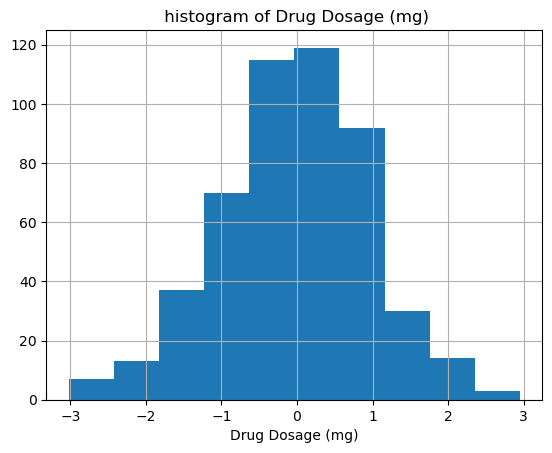

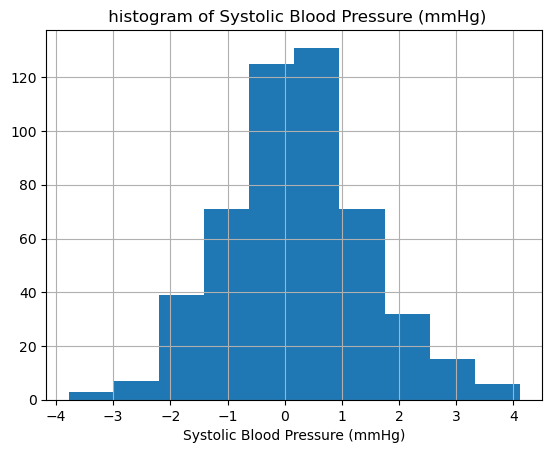

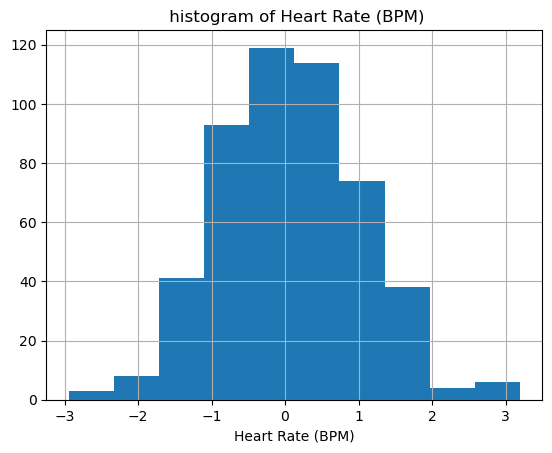

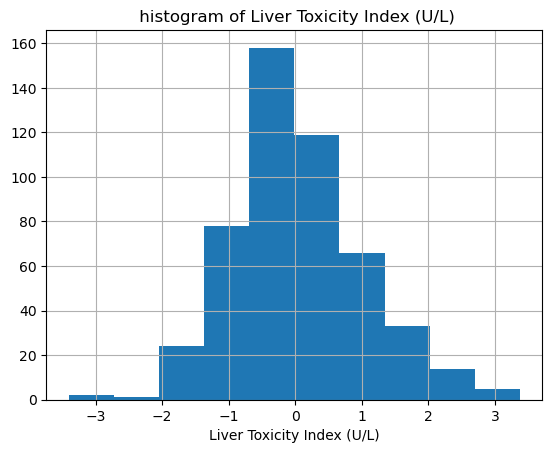

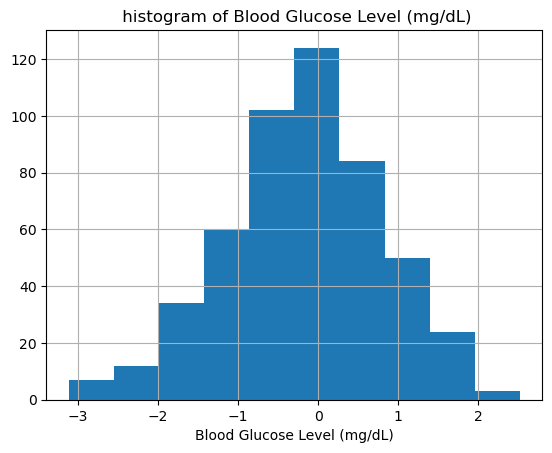

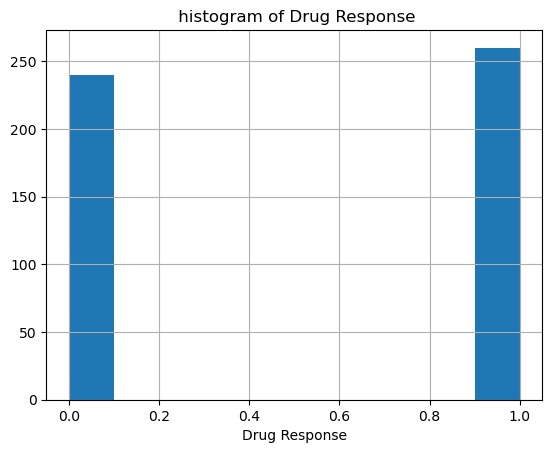

In [5]:
# Performing histogram for dataset 
import matplotlib.pyplot as plt
for i in df.select_dtypes(include="number").columns:
    df[i].hist()
    plt.xlabel(i)
    plt.title(f" histogram of {i}")
    plt.show()

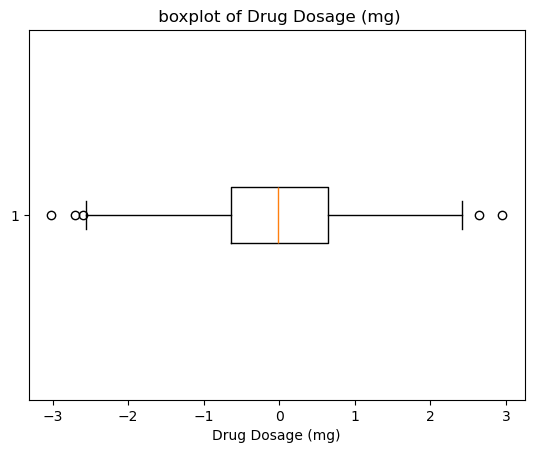

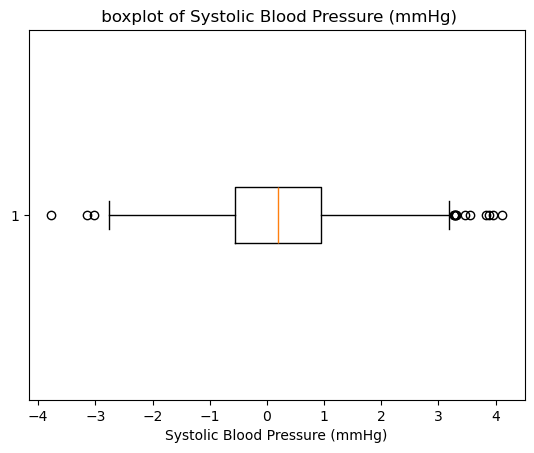

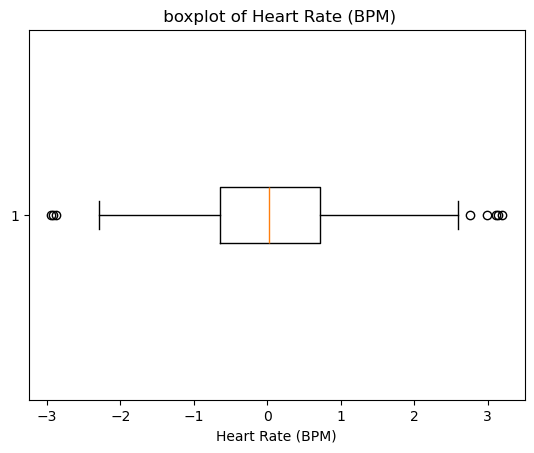

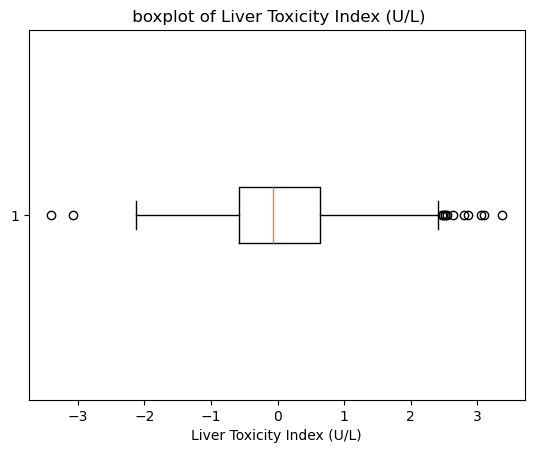

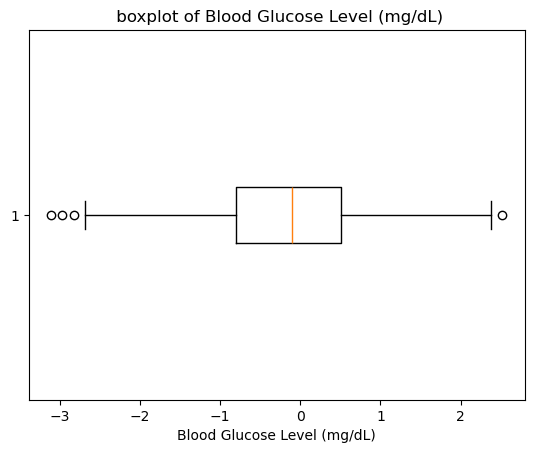

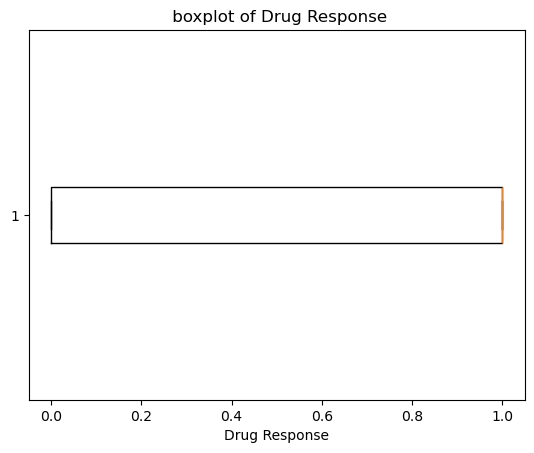

In [6]:
# Performing boxplot for variables
for y in df.select_dtypes(include="number").columns:
    plt.boxplot(x=df[y],vert=False)
    plt.xlabel(y)
    plt.title(f" boxplot of {y}")
    plt.show()


<h4>3.	Investigate feature correlations to discern relationships within the data.</h4>

In [7]:
df.corr()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
Drug Dosage (mg),1.000000,0.090618,0.040571,0.128127,0.012434,0.043457
Systolic Blood Pressure (mmHg),0.090618,1.000000,-0.039195,0.283672,0.037228,0.305226
Heart Rate (BPM),0.040571,-0.039195,1.000000,0.005818,0.049897,-0.009715
Liver Toxicity Index (U/L),0.128127,0.283672,0.005818,1.000000,0.229474,0.434722
Blood Glucose Level (mg/dL),0.012434,0.037228,0.049897,0.229474,1.000000,0.169342
Drug Response,0.043457,0.305226,-0.009715,0.434722,0.169342,1.000000


<h4>Task 2: Data Preprocessing</h4>

<h4>1.	Encode categorical variables if necessary.</h4>

In [8]:
# This variables already in encoding but making the values range from 0 to 1.
# For svm models the transformation data should be 0 to 1  so that model predicts with best accuracy.
from sklearn.preprocessing import MinMaxScaler
MM = MinMaxScaler()
MM_X = MM.fit_transform(df.iloc[:,:5])
MM_X = pd.DataFrame(MM_X)
MM_X.columns=list(df.iloc[:,:5])
MM_X

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,0.484363,0.517038,0.172583,0.540193,0.411911
1,0.196583,0.841914,0.327852,0.925237,0.424803
2,0.296069,0.283082,0.538685,0.454039,0.586617
3,0.839732,0.333659,0.354403,0.646031,0.406342
4,0.569080,0.546855,0.474627,0.781941,0.382041
...,...,...,...,...,...
495,0.245577,0.542864,0.612746,0.404460,0.313592
496,0.598295,0.695976,0.534928,0.754860,0.464446
497,0.326168,0.450535,0.518405,0.666347,0.501842
498,0.784232,0.509743,0.404874,0.595557,0.669428


<h4>2.	Split the dataset into training and testing sets.</h4>

In [9]:
# Separating the x and y variables 
x=df.drop("Drug Response",axis=1)
y=df["Drug Response"]

# Importing appropriate libraries 
from sklearn.model_selection import train_test_split
# Splitting the data into training an testing
x_train,x_test,y_train,y_test=train_test_split(MM_X,y,test_size=0.2,random_state=42)


<h4>Task 3: Data Visualization</h4>

<h4>1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.</h4>

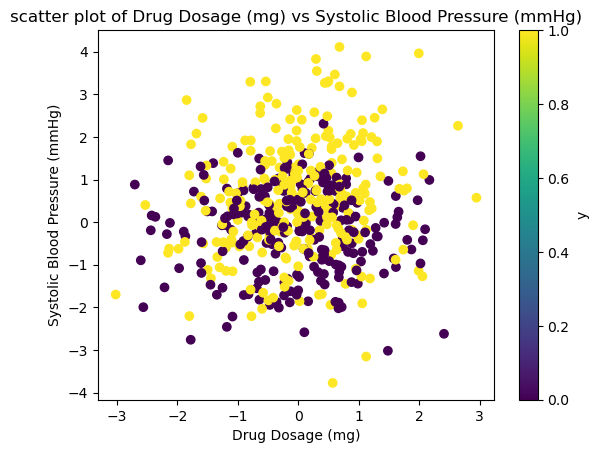

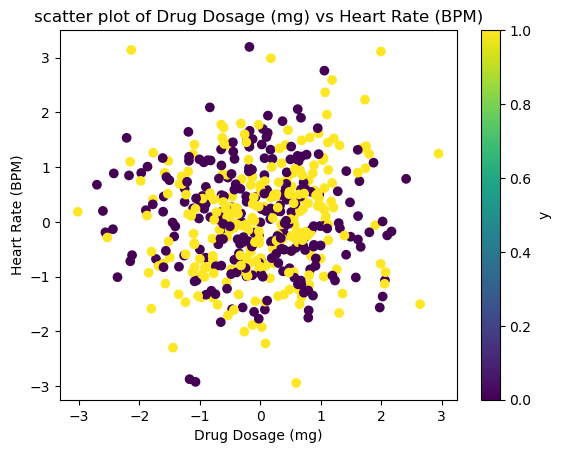

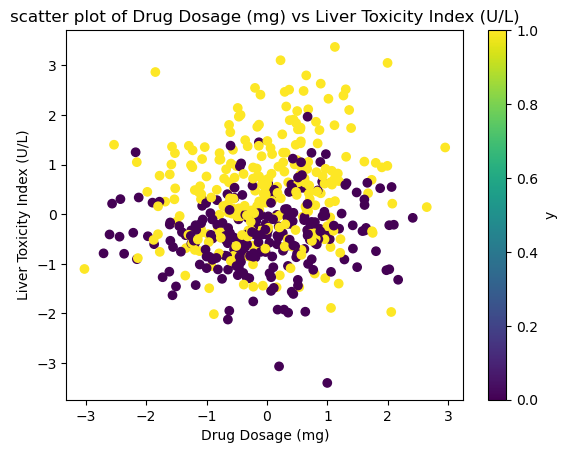

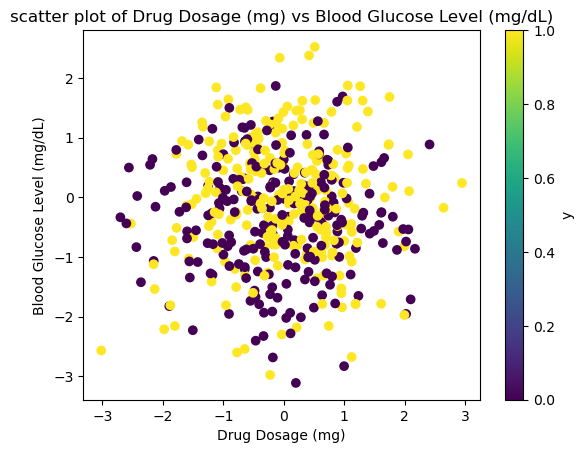

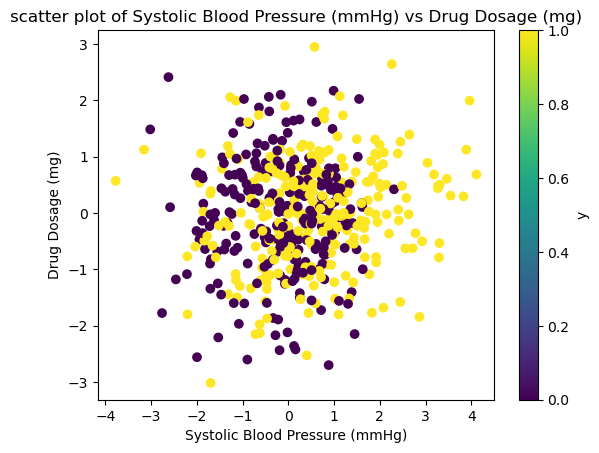

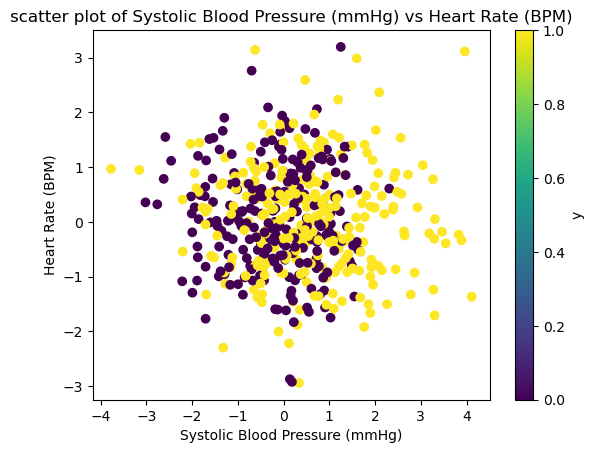

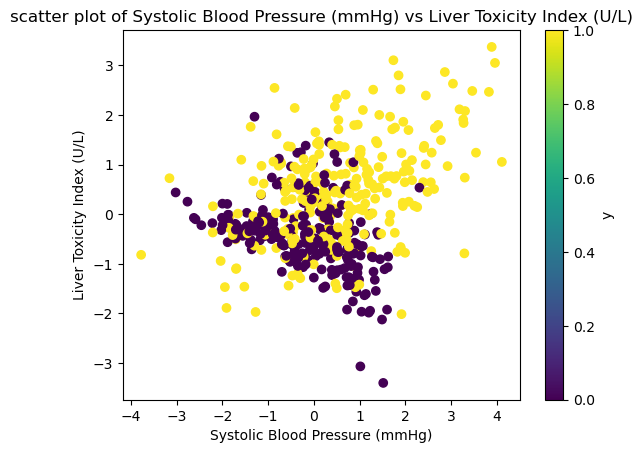

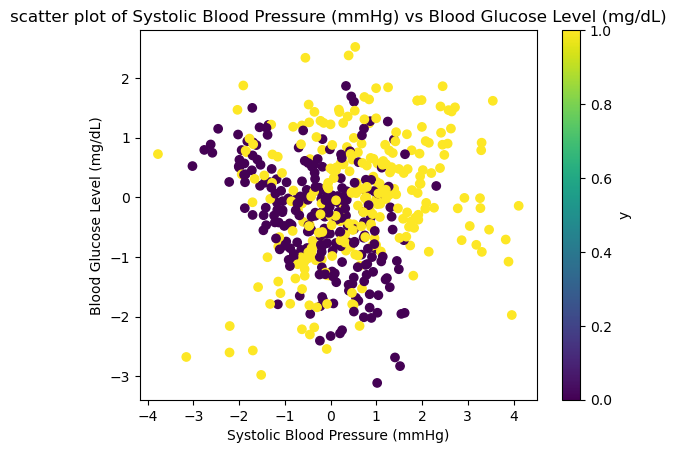

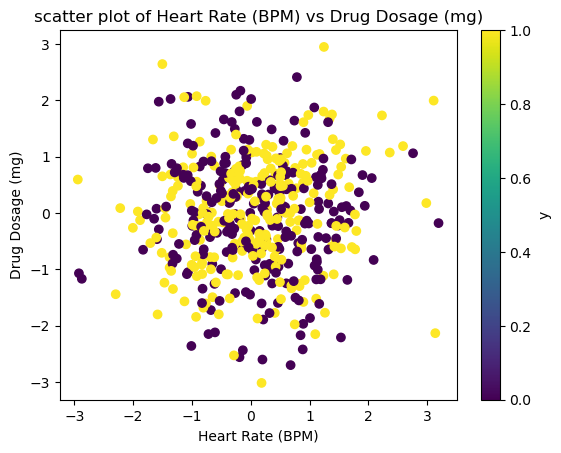

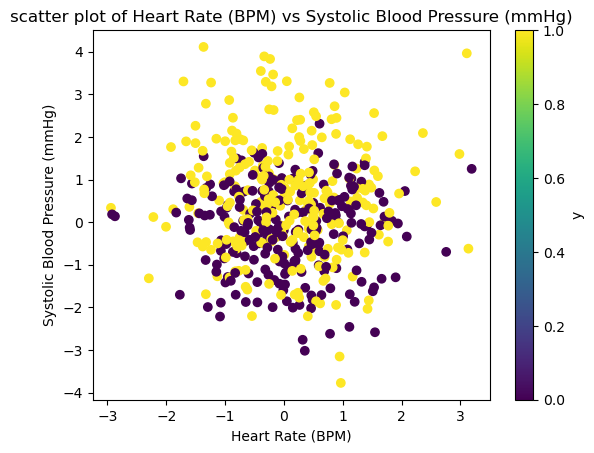

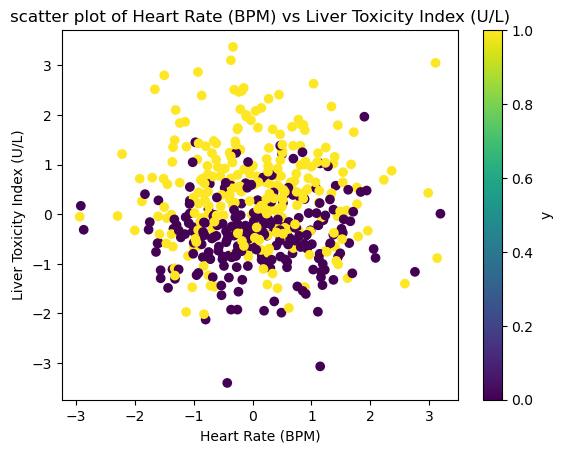

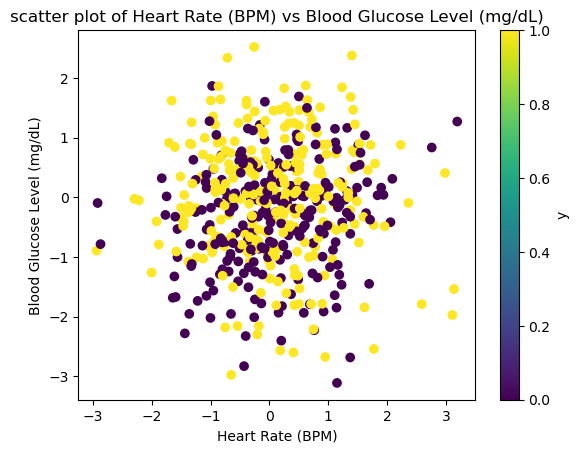

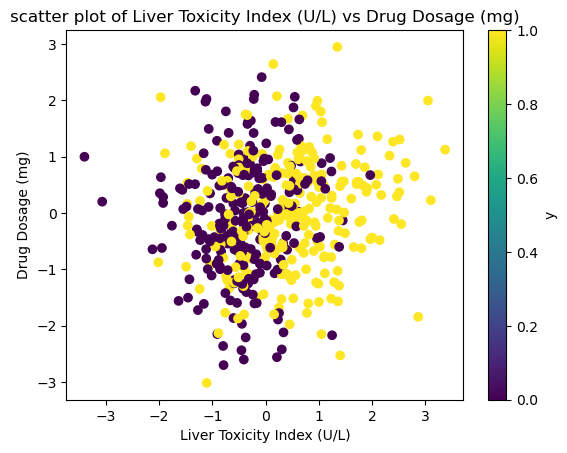

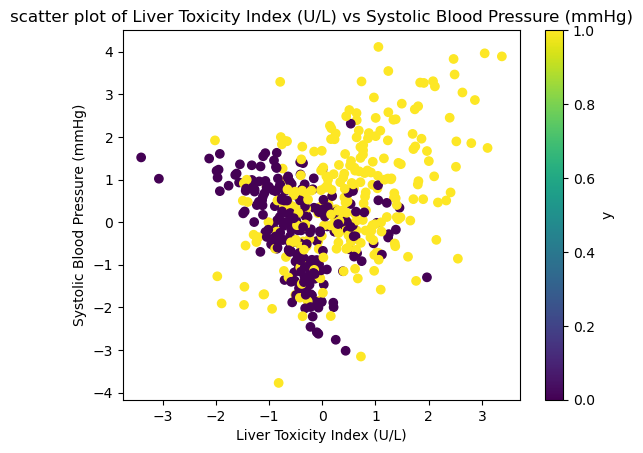

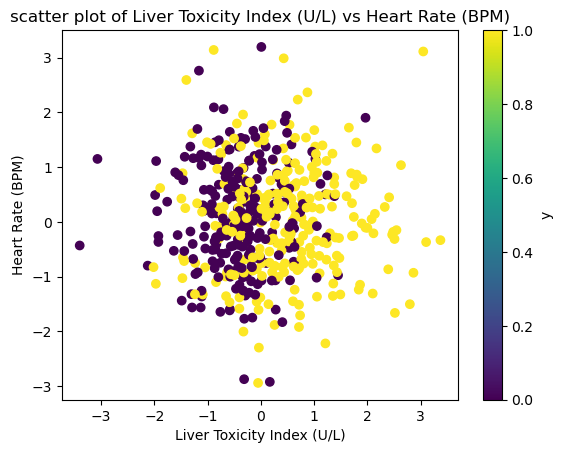

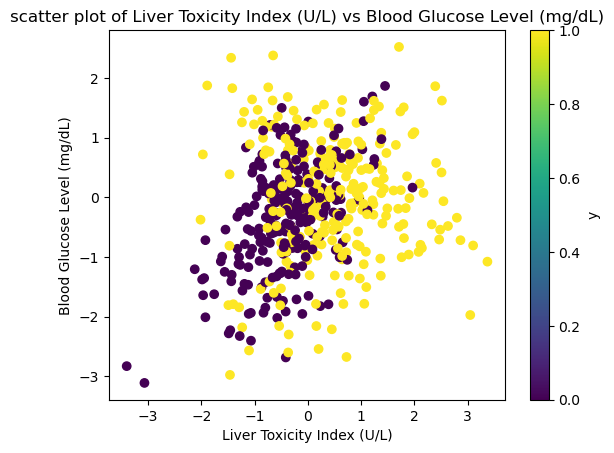

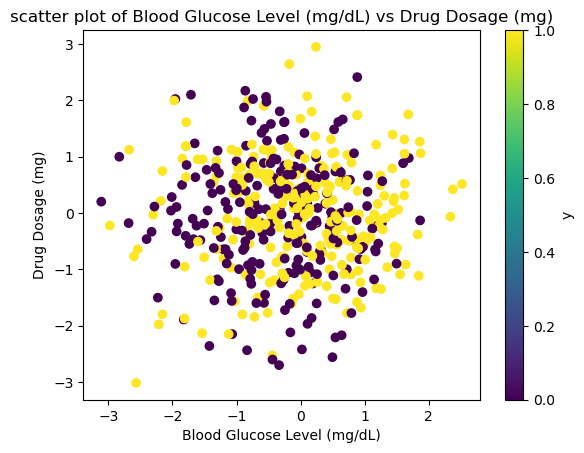

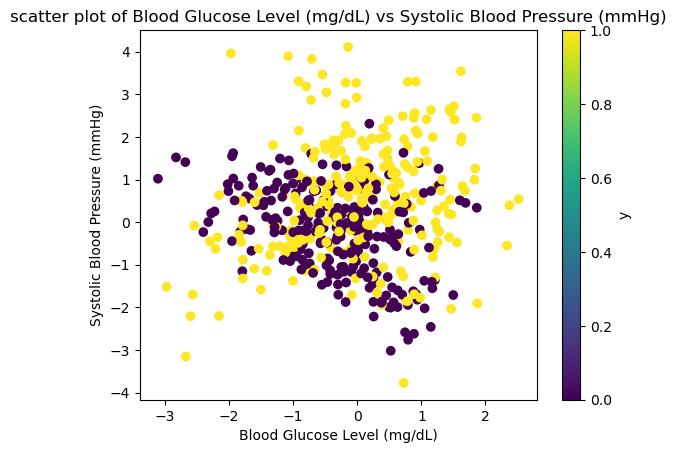

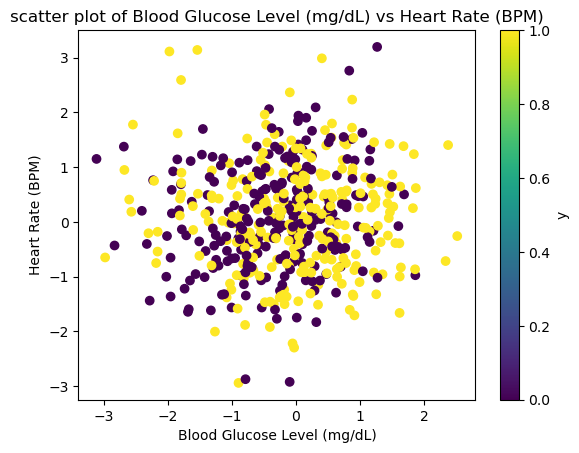

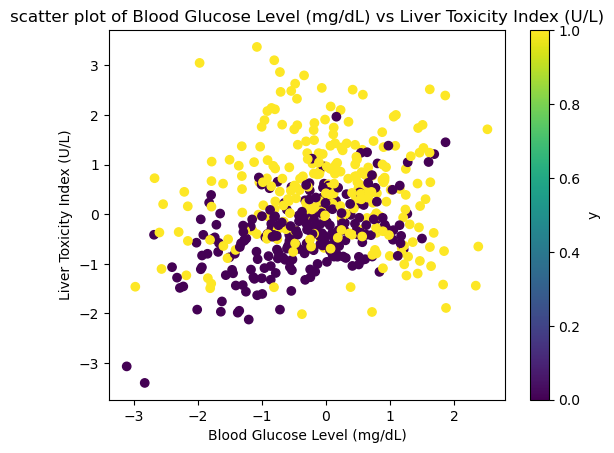

In [10]:
# Performing scatter plot 
import matplotlib.pyplot as plt
for i in x:
    for j in x:
        if i!=j:
            plt.scatter(df[i],df[j],c=y,cmap="viridis")
            plt.xlabel(i)
            plt.ylabel(j)
            plt.title(f"scatter plot of {i} vs {j}")
            plt.colorbar(label="y")
            plt.show()



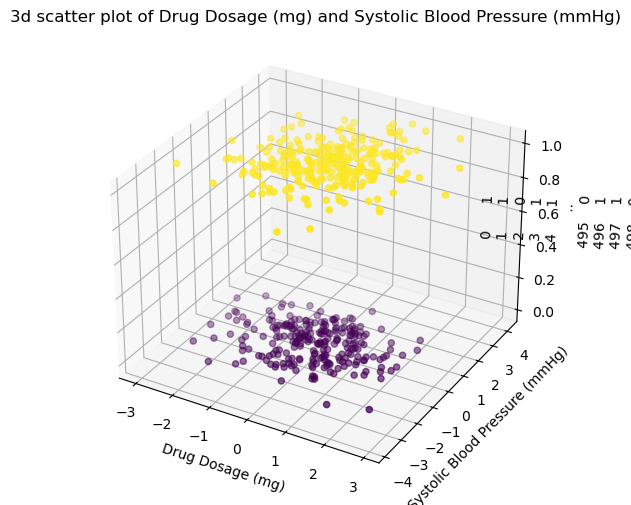

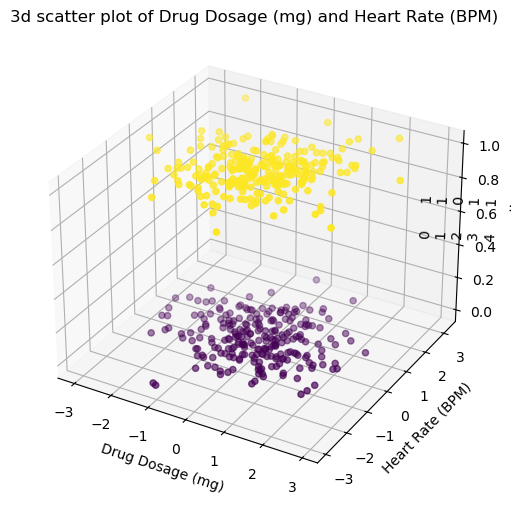

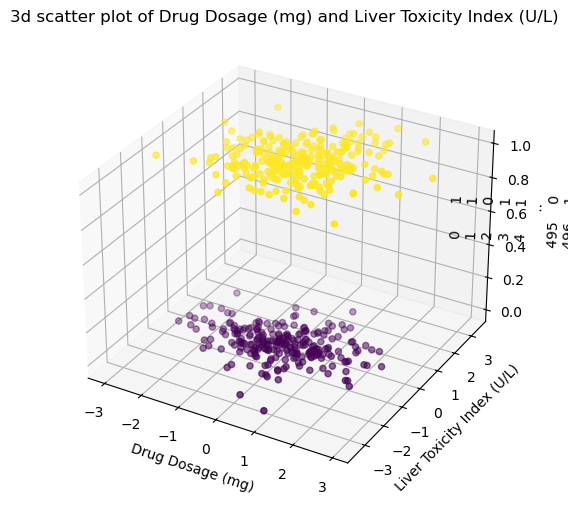

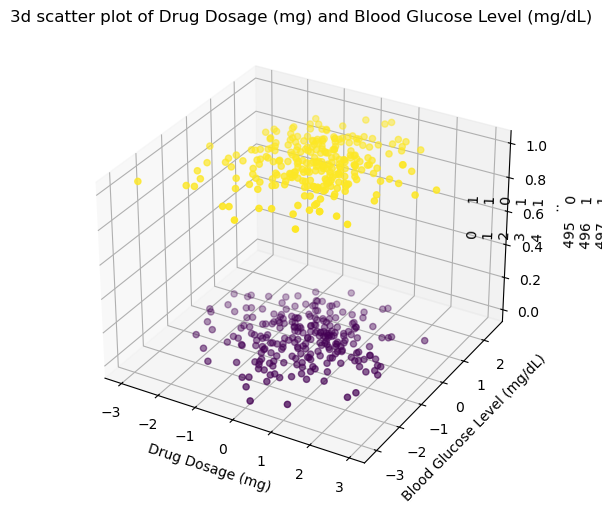

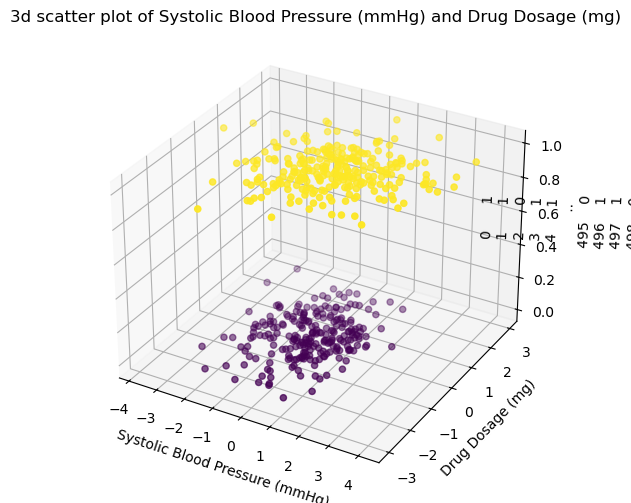

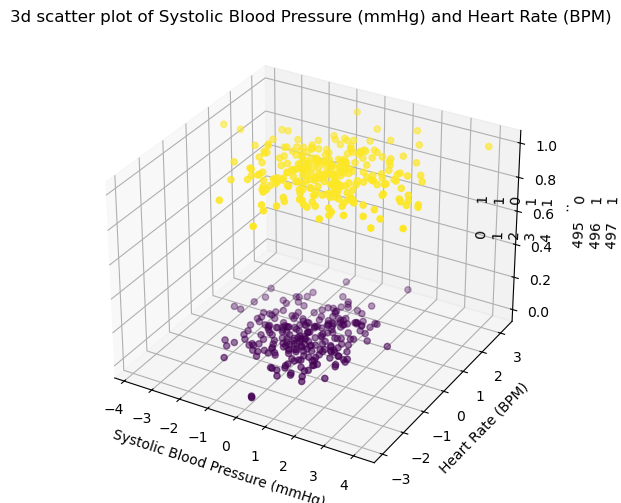

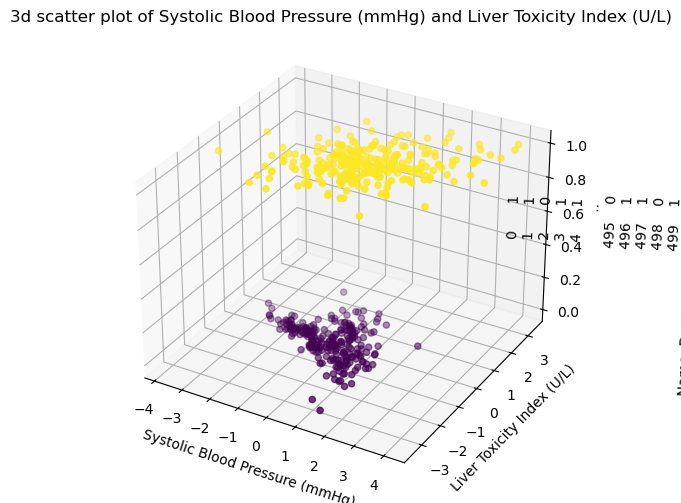

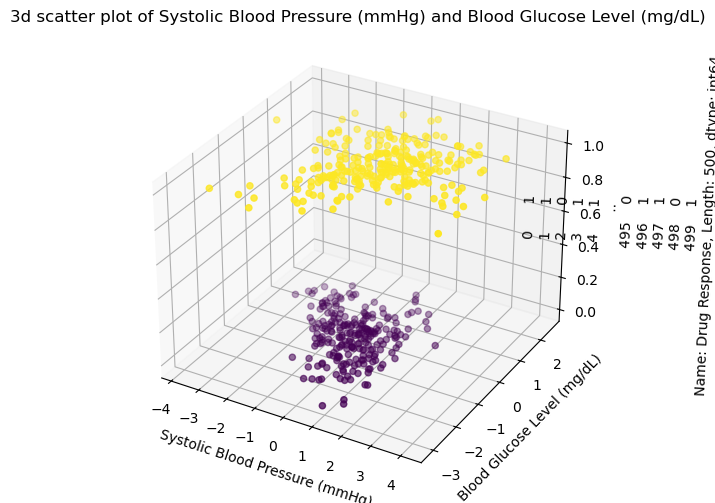

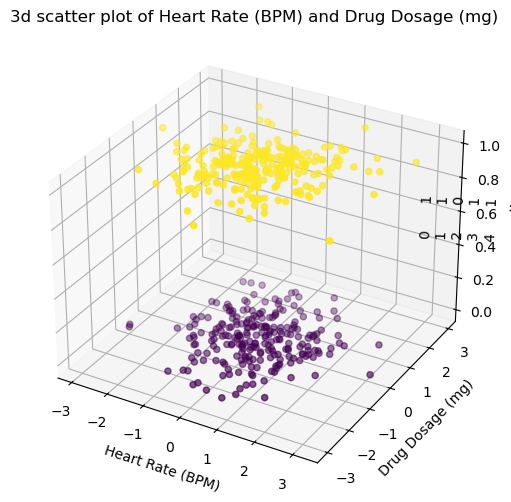

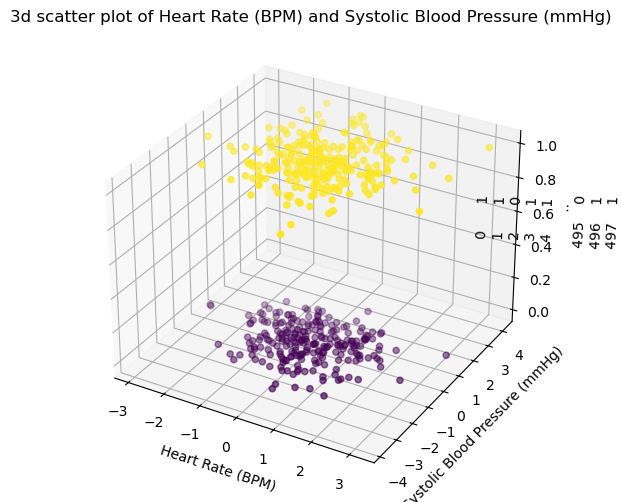

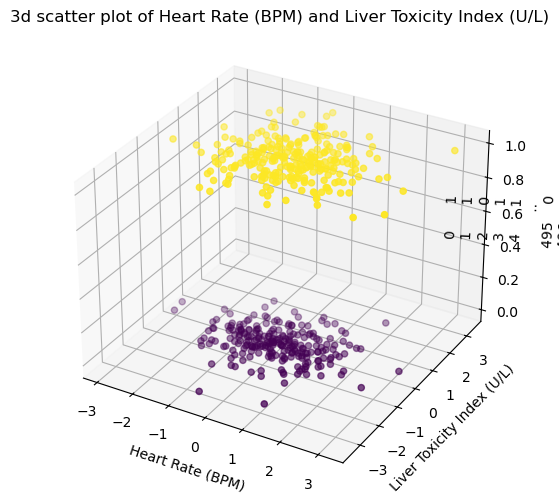

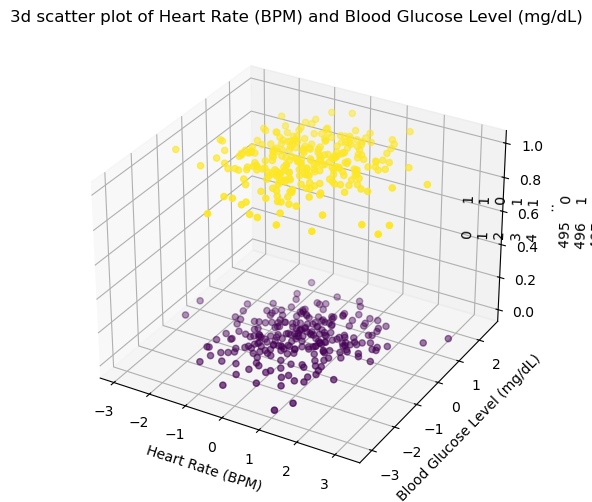

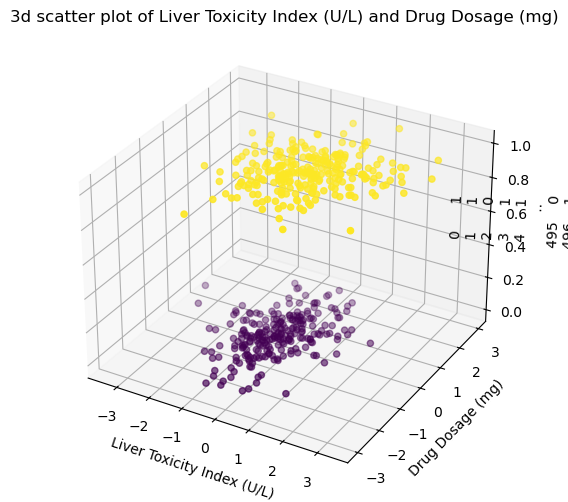

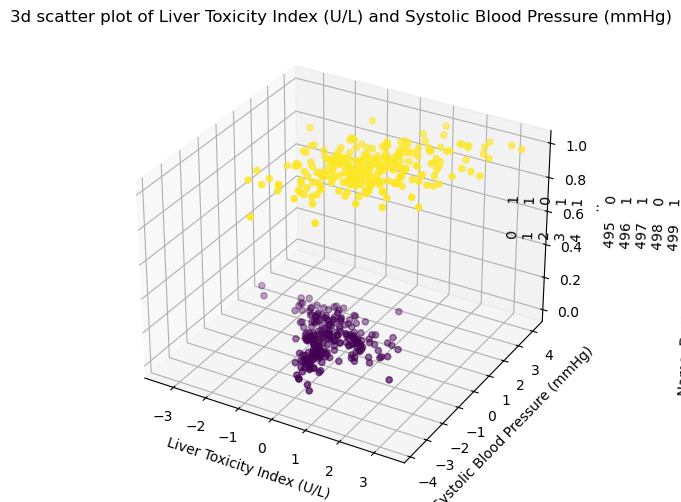

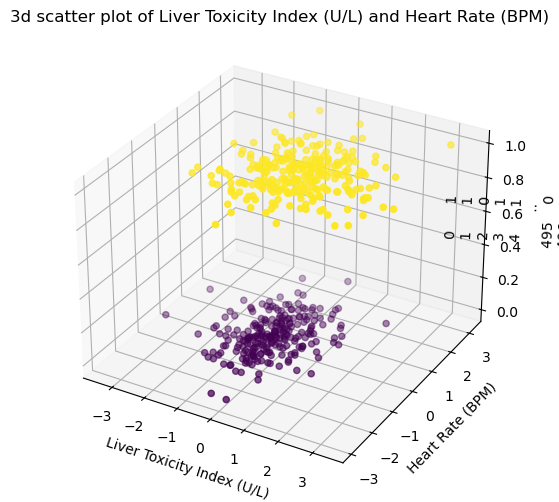

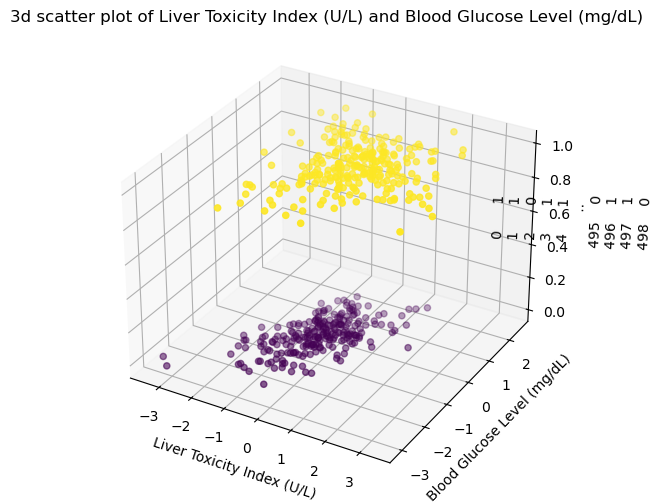

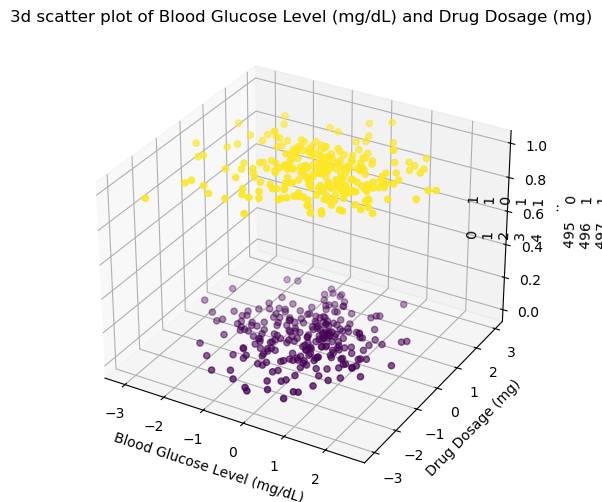

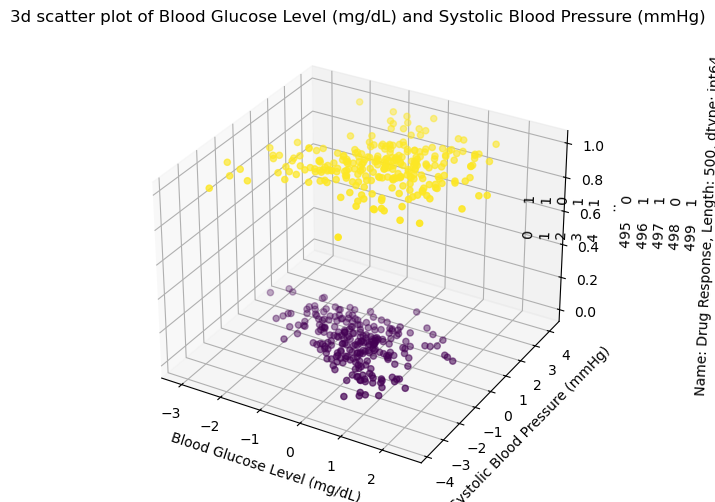

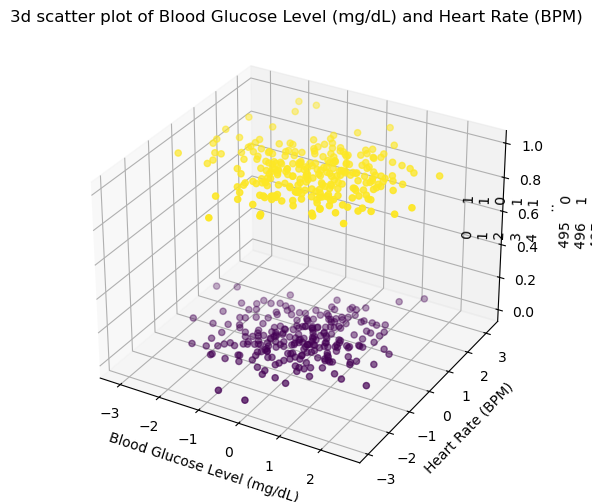

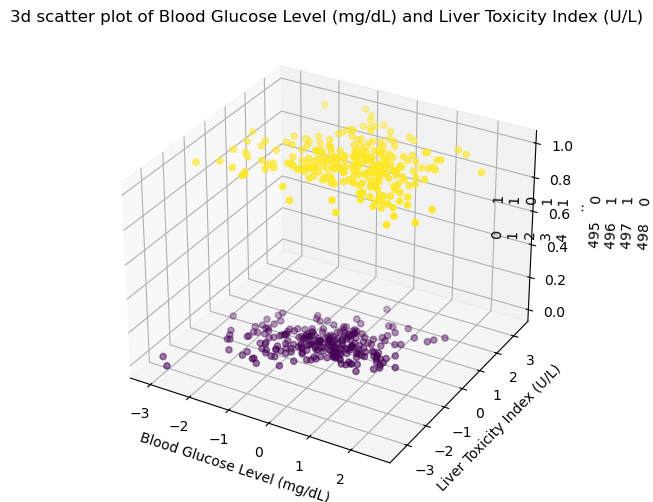

In [11]:
# Seperating models by using svm for  non linearity data.
# Plotting the 3d scatter plot of a data.
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

for k in x:
    for m in x:
        if k!=m:
            fig=plt.figure(figsize=(8,6))
            ax=fig.add_subplot(111,projection="3d")
            ax.scatter(x[k],x[m],y,c=y,cmap="viridis")
            ax.set_xlabel(k)
            ax.set_ylabel(m)
            ax.set_zlabel(y)
            ax.set_title(f"3d scatter plot of {k} and {m}")
            plt.show()

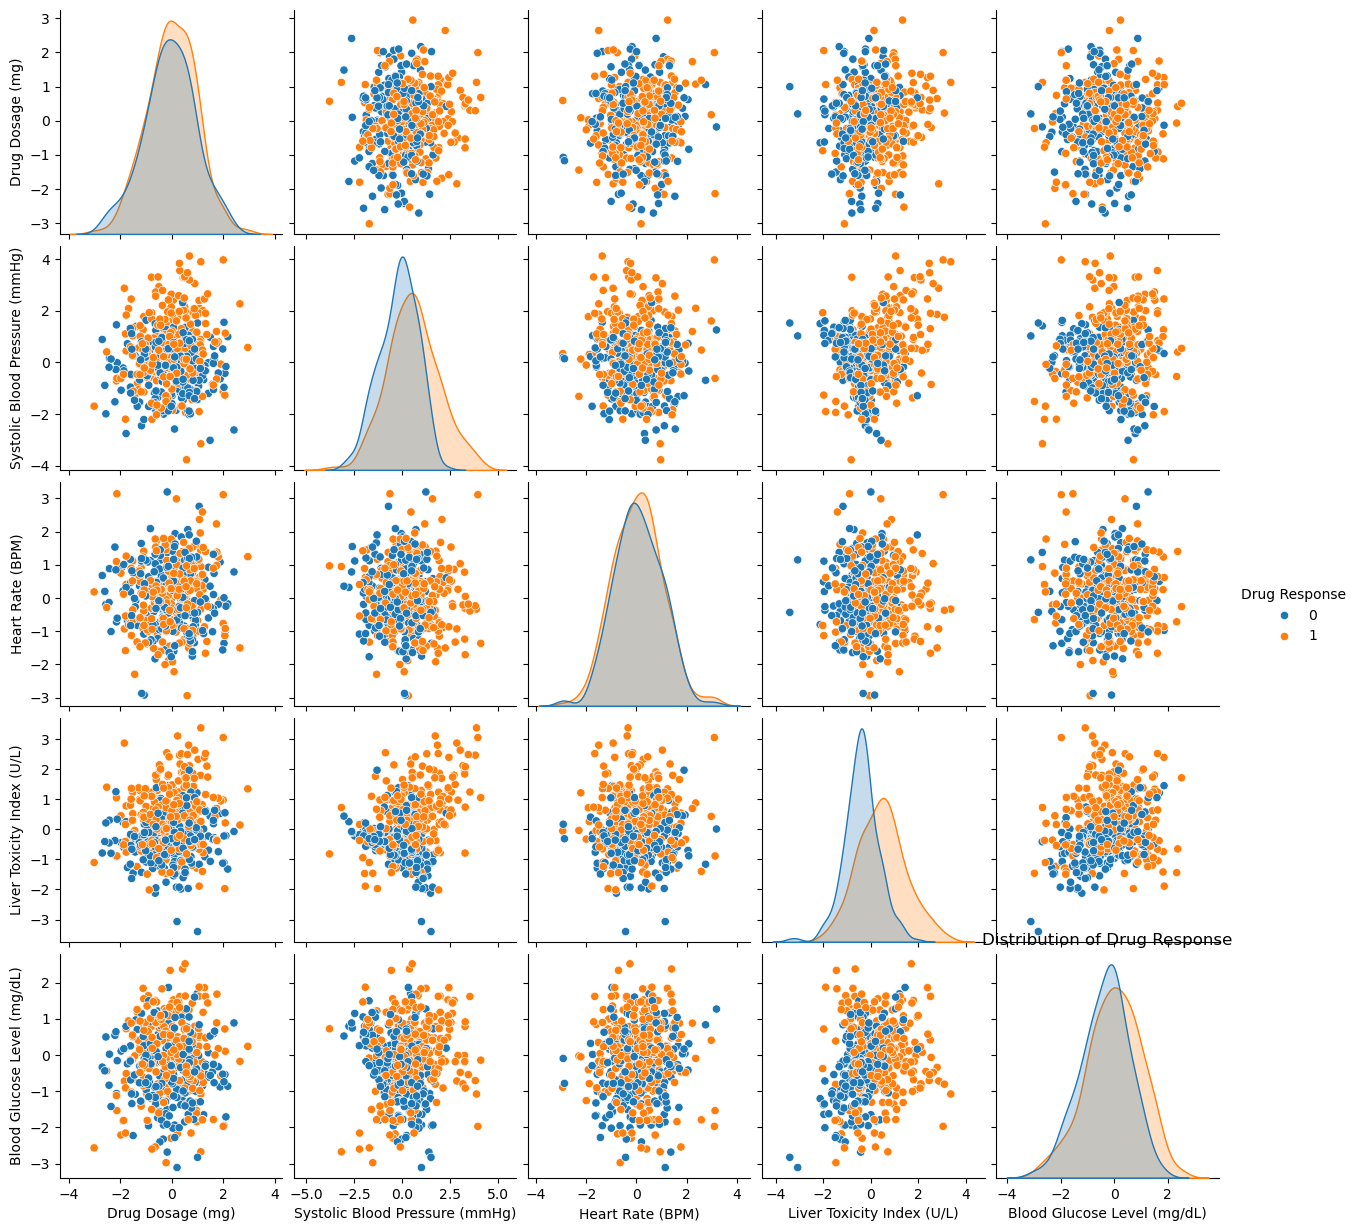

In [12]:
# Performing pairplots for dataset.
import seaborn as sns
a=[]
for i in df.select_dtypes(include="number").columns:
    a.append(i)
sns.pairplot(df[a],hue="Drug Response")
# plt.xlabel(i)
plt.title(f"Distribution of {i}")
plt.show()

<h4>2.	Visualize class distributions to gauge dataset balance or imbalance.</h4>

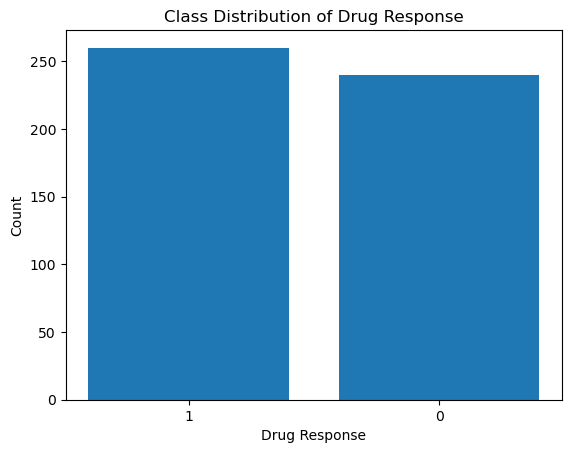

In [13]:
# Only target variable is present in the form of categorical variable
# plotting bar graph for the target variable.
import matplotlib.pyplot as plt

counts = df["Drug Response"].value_counts()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Drug Response")
plt.ylabel("Count")
plt.title("Class Distribution of Drug Response")
plt.show()


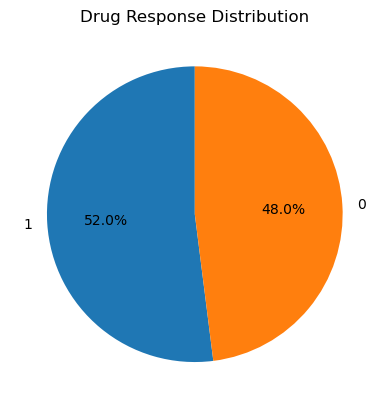

In [14]:
# Plotting the pie chart for the categorical variable.
plt.pie(
    df["Drug Response"].value_counts(),
    labels=df["Drug Response"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Drug Response Distribution")
plt.show()


<h4>Task 4: SVM Implementation</h4>

<h4>1.	Implement a basic SVM classifier using Python libraries like scikit-learn.</h4>

In [15]:
# Implementing the basic SVM Classifier
import numpy as np
from sklearn.svm import SVC

# Kernal as linear and regularizatin(C) as 1 and fitting the model
model=SVC(kernel="linear",C=1)
model.fit(x_train,y_train)

# Training the model.
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

# Calculating the accuracy score.
from sklearn.metrics import accuracy_score

score_1=accuracy_score(y_train,y_pred_train)
score_2=accuracy_score(y_test,y_pred_test)


print(f"the train_score: {np.round(score_1,2)}")
print(f"the test_score: {np.round(score_2,2)}")

the train_score: 0.7
the test_score: 0.76


<h4>2.	Train the SVM model on the training data.</h4>

Already we have trained SVM model in the above task. 

<h4>3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).</h4>

In [16]:
# Checking the test score, precision, f1 score and recall.

import numpy as np
from sklearn.metrics import recall_score,precision_score,f1_score

test_score=accuracy_score(y_test,y_pred_test)
print(f"test score is: {np.round(test_score,2)}")

r_score=recall_score(y_test,y_pred_test)
print(f"the sensitivity is: {np.round(r_score,2)}")

s_score=recall_score(y_pred_test,y_test)
print(f"the specificity is: {np.round(s_score,2)}")

p_score=precision_score(y_test,y_pred_test)
print(f"the precision_score is: {np.round(p_score,2)}")

f1score=f1_score(y_test,y_pred_test)
print(f"the f1_score is: {np.round(f1score,2)}")

test score is: 0.76
the sensitivity is: 0.7
the specificity is: 0.85
the precision_score is: 0.85
the f1_score is: 0.76


<h4>Task 5: Visualization of SVM Results</h4>

<h4>1.	Visualize classification results on the testing data.</h4>

In [17]:
# Showing Confusion matrix for test data to show the result.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred_test)
print(f"the confusion matrix: {cm}")

the confusion matrix: [[37  7]
 [17 39]]


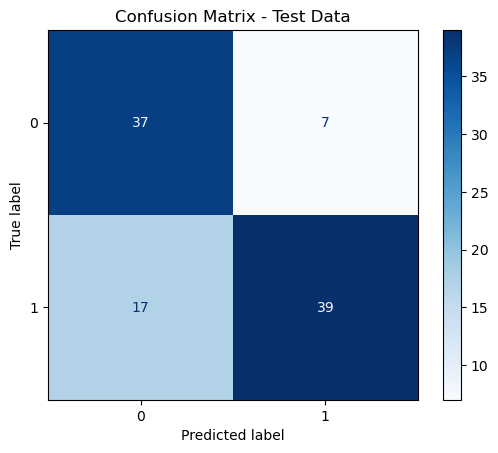

In [18]:
# Visulaizing the confusion matrix
# Showing how many samples were correctly/incorrectly predicted
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm1 = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1,display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Test Data")
plt.show()


<h4>Task 6: Parameter Tuning and Optimization</h4>

<h4>1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.</h4>

In [19]:
# Taking simple linear model with different regularization values.

import numpy as np
from sklearn.svm import SVC
model=SVC(kernel="linear",C=1) 
model.fit(x_train,y_train)      
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)


from sklearn.metrics import accuracy_score

score_1=accuracy_score(y_train,y_pred_train)
score_2=accuracy_score(y_test,y_pred_test)


print(f"the train_score: {np.round(score_1,2)}")
print(f"the test_score: {np.round(score_2,2)}")

the train_score: 0.7
the test_score: 0.76


In [20]:
# Taking the polynomial model with degree valye 1

import numpy as np
from sklearn.svm import SVC
model=SVC(kernel="poly",degree=1)
model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)


from sklearn.metrics import accuracy_score

score_1=accuracy_score(y_train,y_pred_train)
score_2=accuracy_score(y_test,y_pred_test)


print(f"the train_score: {np.round(score_1,2)}")
print(f"the test_score: {np.round(score_2,2)}")

the train_score: 0.7
the test_score: 0.77


In [21]:
# Taking the same polynomial method with degree 2

import numpy as np
from sklearn.svm import SVC
model=SVC(kernel="poly",degree=2)
model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)


from sklearn.metrics import accuracy_score

score_1=accuracy_score(y_train,y_pred_train)
score_2=accuracy_score(y_test,y_pred_test)


print(f"the train_score: {np.round(score_1,2)}")
print(f"the test_score: {np.round(score_2,2)}")

the train_score: 0.76
the test_score: 0.81


In [22]:
# Taking the polynomial method with degree 3

import numpy as np
from sklearn.svm import SVC
model=SVC(kernel="poly",degree=3)
model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)


from sklearn.metrics import accuracy_score

score_1=accuracy_score(y_train,y_pred_train)
score_2=accuracy_score(y_test,y_pred_test)


print(f"the train_score: {np.round(score_1,2)}")
print(f"the test_score: {np.round(score_2,2)}")

the train_score: 0.8
the test_score: 0.76


In [23]:
# Taking the polynomial method with degree 3

import numpy as np
from sklearn.svm import SVC
model=SVC(kernel="poly",degree=3)
model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)


from sklearn.metrics import accuracy_score

score_1=accuracy_score(y_train,y_pred_train)
score_2=accuracy_score(y_test,y_pred_test)


print(f"the train_score: {np.round(score_1,2)}")
print(f"the test_score: {np.round(score_2,2)}")

the train_score: 0.8
the test_score: 0.76


<h4>Task 7: Comparison and Analysis</h4>

<h4>1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).</h4>

==> By observing all the methods of svm it shows data has high non linearity.So most of time polynomial and radial basis function with degree 3 works well compare to other models.

==> Well same thing happen here that the models score we can see both polynomial with degree 3 and radial basis function works well and same.

<h4>2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.</h4>

<h5>SVM STRENGTHS FOR DATASET :</h5>


==> Good for generalization.

==> SVM solves the issues of multicolinearity.

==> If kernal is linear and performs well if the relationship bw x and target variable is approx linear.

==> Handles high dimensional numeric features effectively.


<h5> SVM WEAKNESSES FOR DATASET :</h5>

==>  SVM is slow with very large data sets.

==> SVM can struggle if datasets has noise.

==> SVM data contains non linear data , then linear model fails.

==> SVM  requires standardization, otherwise model may perform poorly,training time increases.
    

<h4>3.	Discuss practical implications of SVM in real-world classification tasks.</h4>

==> SVM  are widely used in real world applications where hgh accuracy, robustness and good generalizations.

==> Works well for large features.

==> Better for small and medium datasets.

==> SVM has best seperating hyperplane so that works well for classifications cases.

==> Kernals can helps for complex data.

==> Good generalization.